In [2]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [3]:
!kaggle datasets download -d iammustafatz/diabetes-prediction-dataset
! unzip "diabetes-prediction-dataset.zip"

Dataset URL: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset
License(s): copyright-authors
  0% 0.00/734k [00:00<?, ?B/s]
100% 734k/734k [00:00<00:00, 38.9MB/s]
Archive:  diabetes-prediction-dataset.zip
  inflating: diabetes_prediction_dataset.csv  


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

# Exercise 1 : Understanding the problem and Data Collection

In [5]:
data=pd.read_csv("diabetes_prediction_dataset.csv")

In [6]:
data.head(20)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
data.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [9]:
data['gender'].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


In [10]:
data['smoking_history'].value_counts()

,count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


In [11]:
data['diabetes'].value_counts()

,count
diabetes,
0,91500
1,8500


In [12]:
# we will divide data to 70/30 %
# 70% - for training
# 30% - for testing
x=data.drop(columns='diabetes',axis=1)
y=data['diabetes']

# Exercise 2 : Model Picking and Standardization

Standardizing the data is generally important, especially when using models that rely on distance metrics (like SVM or k-NN) or models that assume normally distributed data (like Logistic Regression).

In [13]:
numerical_features = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical_features = ['gender', 'smoking_history']
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Exercise 3 : Model Training

In [14]:
# Create a pipeline that first preprocesses the data and then applies Logistic Regression
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression())])

# Split the data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=30)

# Train the model
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, output_dict=True)

# Exercise 4 : Evaluation Metrics

In [15]:
print("Accuracy:", accuracy)

Accuracy: 0.9611


The closer the accuracy is to 1, the better the model is at correctly predicting the target variable.

Confusion Matrix:
 [[18162   170]
 [  608  1060]]


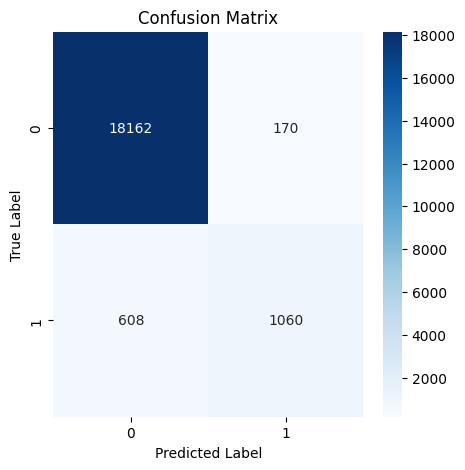

In [16]:
print("Confusion Matrix:\n", conf_matrix)
plt.figure(figsize=(5, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

This image shows a confusion matrix, a tool used in machine learning to evaluate the performance of a classification algorithm. Here's what each part of the matrix represents:

1. **True Labels (Rows):**
   - The rows represent the actual class labels.
   - "0" corresponds to the actual negative class.
   - "1" corresponds to the actual positive class.

2. **Predicted Labels (Columns):**
   - The columns represent the predicted class labels made by the model.
   - "0" corresponds to the predicted negative class.
   - "1" corresponds to the predicted positive class.

### Breakdown of the Matrix:
- **True Negatives (TN):** 18,162 (Top-left corner)
  - The model correctly predicted the negative class ("0") when it was actually negative.

- **False Positives (FP):** 170 (Top-right corner)
  - The model incorrectly predicted the positive class ("1") when it was actually negative ("0").

- **False Negatives (FN):** 608 (Bottom-left corner)
  - The model incorrectly predicted the negative class ("0") when it was actually positive ("1").

- **True Positives (TP):** 1,060 (Bottom-right corner)
  - The model correctly predicted the positive class ("1") when it was actually positive.

### Interpretation:
- **High True Negatives (18,162):** The model is very good at identifying the negative class.
- **Relatively High False Negatives (608):** The model is missing quite a few positive cases, which may indicate a need for improvement in detecting the positive class.
- **Low False Positives (170):** The model rarely misclassifies negative cases as positive.
- **True Positives (1,060):** The model correctly identifies a decent number of positive cases.

Overall, this confusion matrix suggests that the model performs well in identifying negative cases but struggles somewhat with positive cases, leading to a relatively higher number of false negatives.

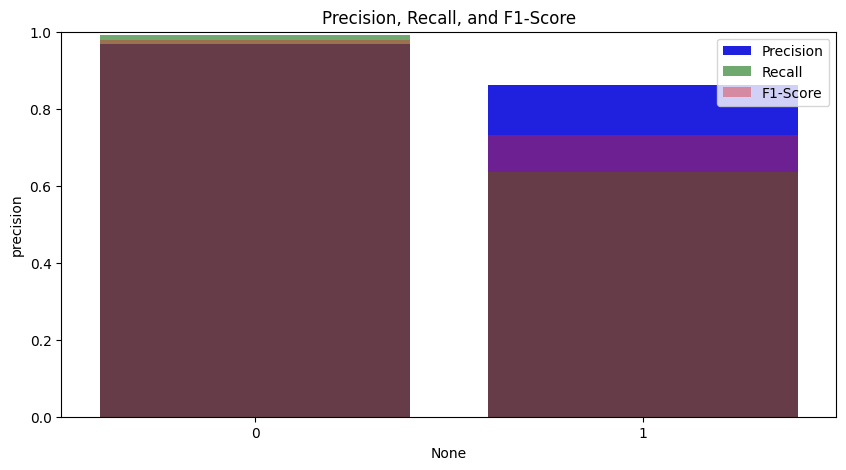

Classification Report:
               precision    recall  f1-score     support
0              0.967608  0.990727  0.979031  18332.0000
1              0.861789  0.635492  0.731539   1668.0000
accuracy       0.961100  0.961100  0.961100      0.9611
macro avg      0.914698  0.813109  0.855285  20000.0000
weighted avg   0.958783  0.961100  0.958390  20000.0000


In [17]:
class_report_df = pd.DataFrame(classification_rep).transpose()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_report_df.index[:-3], y=class_report_df['precision'][:-3], color='blue', label='Precision')
sns.barplot(x=class_report_df.index[:-3], y=class_report_df['recall'][:-3], color='green', label='Recall', alpha=0.6)
sns.barplot(x=class_report_df.index[:-3], y=class_report_df['f1-score'][:-3], color='red', label='F1-Score', alpha=0.4)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.title('Precision, Recall, and F1-Score')
plt.show()

print("Classification Report:\n", pd.DataFrame(classification_rep).transpose())

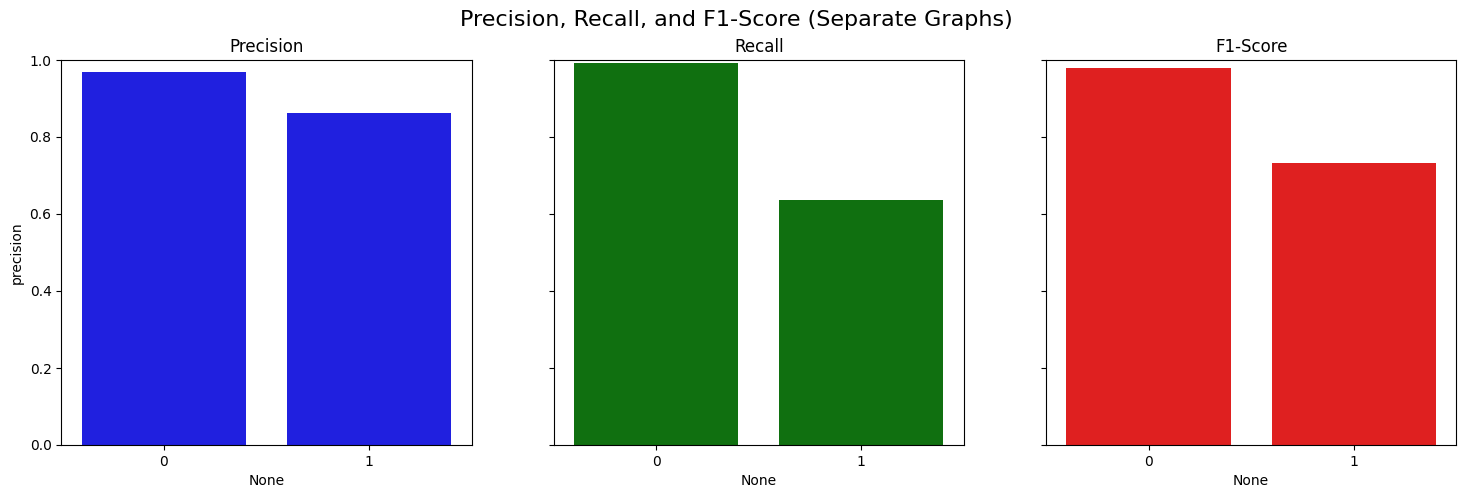

In [18]:
# Create subplots for precision, recall, and F1-score
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot Precision
sns.barplot(x=class_report_df.index[:-3], y=class_report_df['precision'][:-3], color='blue', ax=axes[0])
axes[0].set_title('Precision')
axes[0].set_ylim(0, 1)

# Plot Recall
sns.barplot(x=class_report_df.index[:-3], y=class_report_df['recall'][:-3], color='green', ax=axes[1])
axes[1].set_title('Recall')
axes[1].set_ylim(0, 1)

# Plot F1-Score
sns.barplot(x=class_report_df.index[:-3], y=class_report_df['f1-score'][:-3], color='red', ax=axes[2])
axes[2].set_title('F1-Score')
axes[2].set_ylim(0, 1)

# Set the overall title for the figure
fig.suptitle('Precision, Recall, and F1-Score (Separate Graphs)', fontsize=16)

plt.show()

This image illustrates a bar plot displaying the precision, recall, and F1-score for a binary classification model. Each of these metrics is shown for the two classes, "0" and "1".

### Explanation of the Metrics:
- **Precision:** The ratio of true positive predictions to the total number of positive predictions (true positives + false positives). It reflects how many of the predicted positive cases were actually positive.
  
- **Recall (Sensitivity):** The ratio of true positive predictions to the total number of actual positives (true positives + false negatives). It reflects how many of the actual positive cases were captured by the model.
  
- **F1-Score:** The harmonic mean of precision and recall. It balances the two metrics, providing a single score that accounts for both false positives and false negatives.

### Interpretation:
- **Class "0":**
  - The precision, recall, and F1-score bars are all almost at the top (close to 1), indicating the model is highly accurate in predicting the negative class.
  
- **Class "1":**
  - The precision bar is lower than that for class "0," indicating that the model is less accurate in predicting the positive class.
  - The recall and F1-score are also lower, further confirming that the model is not as effective at identifying and correctly classifying positive cases.

### Overall Interpretation:
- The model performs exceptionally well for class "0" (negative class) with high precision, recall, and F1-score.
- For class "1" (positive class), the performance is not as strong, as indicated by the lower precision, recall, and F1-score. This aligns with the earlier confusion matrix, where we saw a relatively higher number of false negatives and lower true positives for the positive class.

This suggests that while the model is excellent at identifying negatives, there may be room for improvement in recognizing and correctly classifying positives.

# Exercise 5 : Visualizing the performance of our model